In [ ]:
from brian2 import *
sys.path.append('Neuron and Synapse Models')
from neuronModels import *
from ringAttractorClass import *

sys.path.append('Tools')
from plottingTools import *
from utils import *

deviceType = 'cpp_standalone'
deviceType = ''
if deviceType == 'cpp_standalone':
    set_device(deviceType, build_on_run=False)

In [2]:
# Simulation parameters
defaultclock.dt = 0.1*ms

In [3]:
# Setting network parameters
num_neurons = 120
tau=10*ms
sigma_noise=0.1*mV
V_rest=-70*mV

In [4]:
# External input: a spatially modulated current.

# For example, we define a Gaussian input centered at a particular position (stimulus_center)
stimulus_center = 3.14  # center of the bump on the ring
stimulus_width = 0.5  # width in radians
I0 = 30*mV         # amplitude of the external input

# Define the external input as a function of neuron position
positions = linspace(0, 2*pi, num_neurons, endpoint=False)
# I_ext_array = I0 * exp(-((positions - stimulus_center)**2) / (2 * stimulus_width**2))
# d = np.angle(np.exp(1j * (positions - stimulus_center)))
d = arctan2(sin(positions - stimulus_center), cos(positions - stimulus_center))

I_ext_array = I0 * np.exp(-(d**2) / (2 * stimulus_width**2))

In [5]:
# Creating the equation object
neuron_eq = Equations(LIF_xi_vel_eq, tau=tau, V_rest=V_rest, sigma_noise=sigma_noise)

In [6]:
# # Connectivity parameters - Mexican hat
# sigma_exc = 0.0875
# sigma_inh = 0.25
# g_exc = 1.0*mV
# g_inh = -0.475*mV

# Testing values
sigma_exc_val= 0.125
sigma_inh_val= 0.25
g_exc= 0.875*mV
g_inh= -0.475*mV

# Connectivity parameters - Cosine
g_cosine = 0.1*mV
w_inh = -0.555*mV

# Create neuron group
Vth=-48*mV
V_reset=-80*mV
refractory_period=5*ms
glob_inh_flag = True
            
ringAttractor = RingAttractor(neuron_eq, 
                        num_neurons, 
                        Vth, V_reset, refractory_period,
                        syn_profile='cosine',
                        autapse=True,
                        glob_inh=glob_inh_flag, w_inh=w_inh,
                        g_cosine=g_cosine,
                        sigma_exc=sigma_exc_val, sigma_inh=sigma_inh_val,
                        g_exc=g_exc, g_inh=g_inh)

ringAttractor.ring_pool.I_ext = I_ext_array
ringAttractor.ring_pool.I_vel = 0.0

ringAttractor.ring_pool.run_regularly('V = clip(V, V_reset, inf*volt)', dt=defaultclock.dt)

CodeRunner(clock=Clock(dt=100. * usecond, name='ring_neurons_run_regularly_clock'), when=start, order=0, name='ring_neurons_run_regularly')

In [7]:
# Setup monitors: spike monitor and state monitor for membrane potential and external input
spikemon = SpikeMonitor(ringAttractor.ring_pool)
statemon = StateMonitor(ringAttractor.ring_pool, 'V', record=True)
inputmon = StateMonitor(ringAttractor.ring_pool, 'I_ext', record=True)  # if you want to check the input

# Set of Brian objects to be added to the network
localObjects = [spikemon, statemon, inputmon] # enforce_lower_bound]

if glob_inh_flag:
    statemon_inh = StateMonitor(ringAttractor.glob_inh_neuron, 'V', record=True)
    spikemon_inh = SpikeMonitor(ringAttractor.glob_inh_neuron)
    localObjects.extend([statemon_inh, spikemon_inh])
    

net = Network(ringAttractor.BrianObjects+localObjects)

    
input_on = 0.5 * second
input_off = input_on
velocity_on = 0.5 * second
sim_duration = 2 * second
end_duration = sim_duration - input_on - input_off - velocity_on

# Run simulation
net.run(input_on)

# Turn off input for the second half
ringAttractor.ring_pool.I_ext = I_ext_array * 0
net.run(input_off)

# Turn on velocity input
ringAttractor.ring_synapses_asym.vel_in = 0.0
    
net.run(velocity_on)

# Turn off velocity input
ringAttractor.ring_synapses_asym.vel_in = 0.0

# Turn off velocity input and run for the rest of the duration
net.run(end_duration)

WARNING    'w_inh' is an internal variable of group 'glob_inh2pool', but also exists in the run namespace with the value -0.555 * mvolt. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [8]:
if deviceType == 'cpp_standalone':
    device.build(directory = 'model_build', compile=True, run=True, debug=False, clean=False)

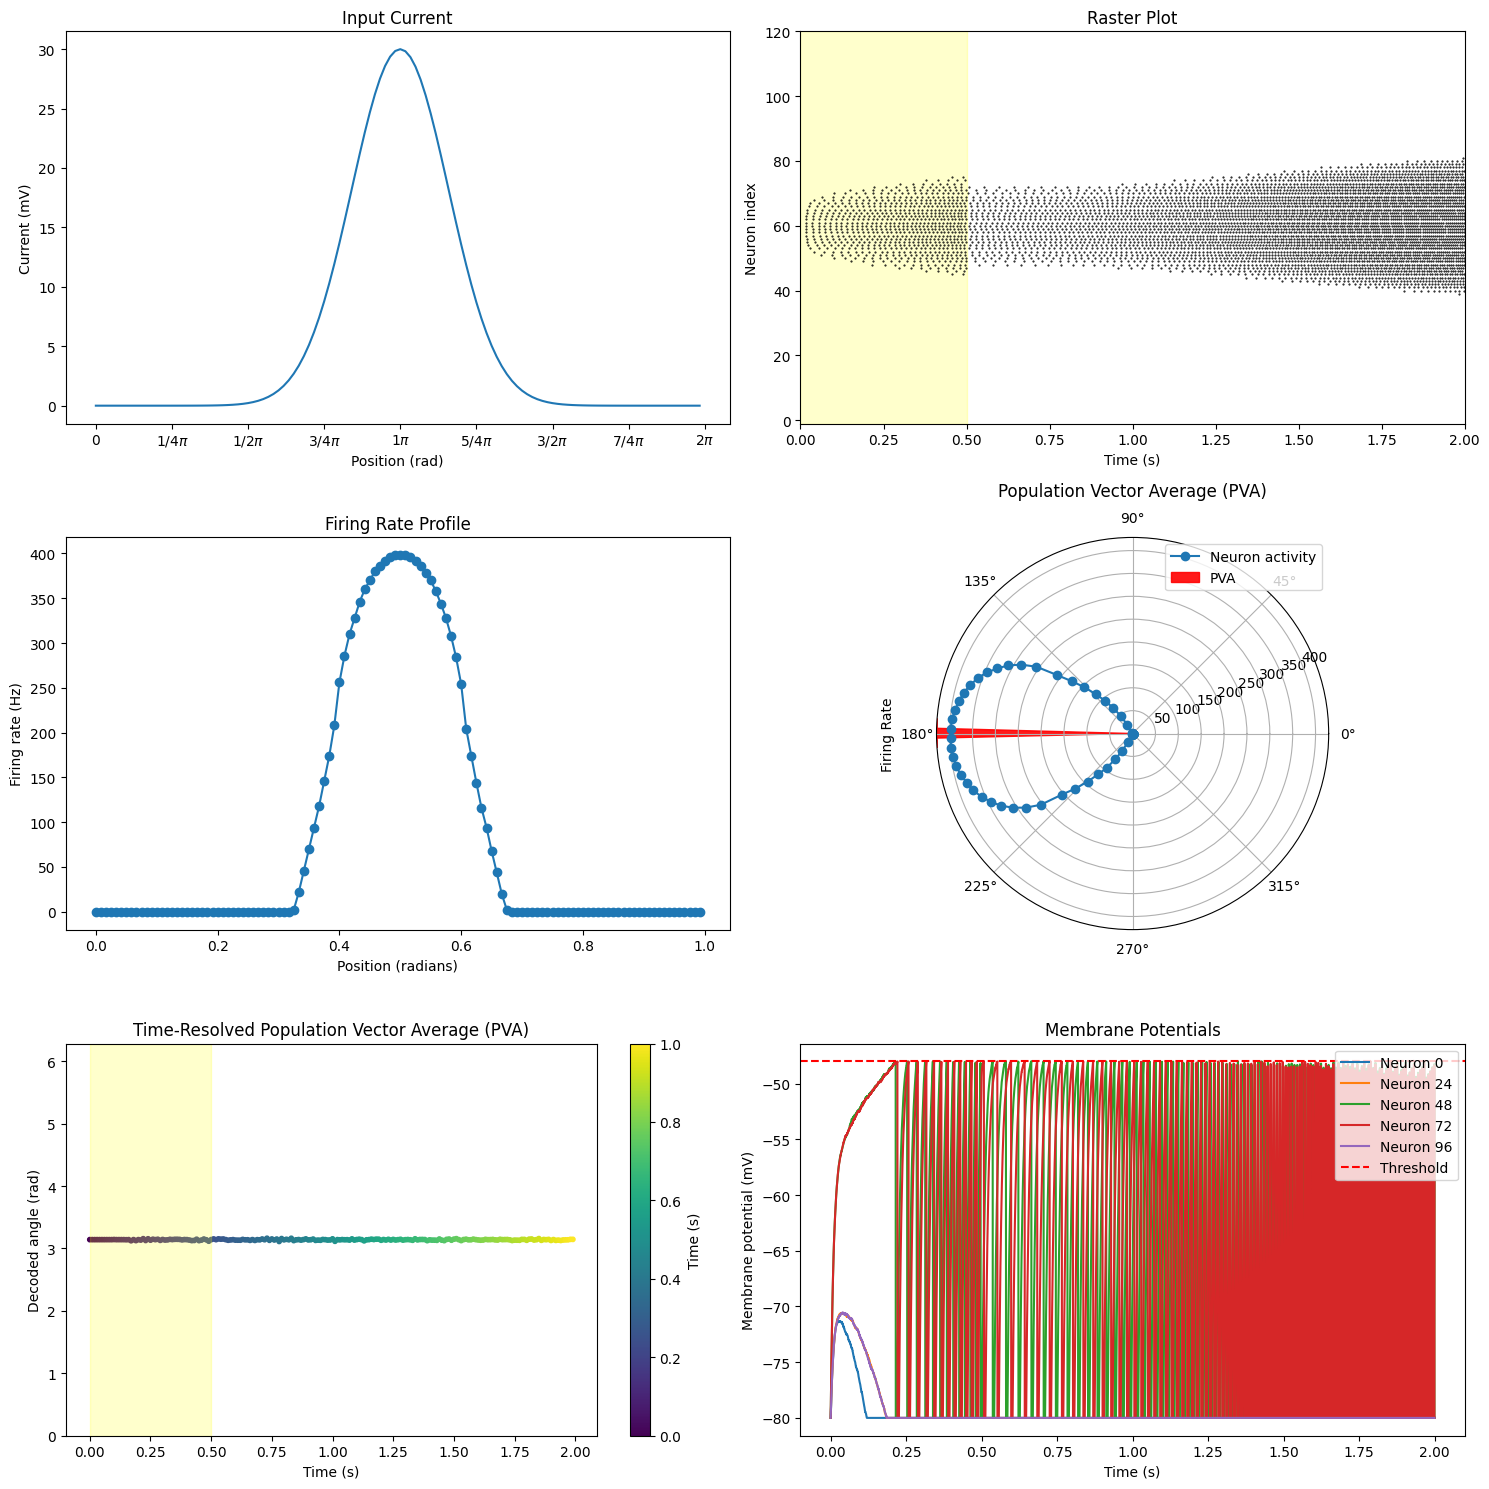

In [9]:
from matplotlib.ticker import FuncFormatter
from sympy import Rational

#+---------------------------------------------------------------------------+
#|                           Plotting the Results                            |
#+---------------------------------------------------------------------------+

# Create a figure with 6 subplots arranged in 3 rows and 2 columns
fig = plt.figure(figsize=(15, 15))

# 1. Input Current Plot
ax1 = fig.add_subplot(3, 2, 1)
ax1.plot(positions/pi, I_ext_array/mV)
# Define the formatter function
def pi_formatter(x, pos):
    # Convert the value to a fraction of pi
    frac = Rational(x).limit_denominator(10)  # Limit denominator to avoid too large fractions
    if frac == 0:
        return r"$0$"
    elif frac == 2:
        return r"$2\pi$"
    else:
        return r"${}\pi$".format(frac)

# Set the custom formatter for the x-axis
ax1.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
ax1.set_title('Input Current')
ax1.set_xlabel('Position (rad)')
ax1.set_ylabel('Current (mV)')


# 2. Raster Plot
ax2 = fig.add_subplot(3, 2, 2)
raster_plot(spikemon, ax=ax2, stim_periods=(0*second, input_on),
            stim_display_method='highlight', duration=sim_duration, num_neurons=num_neurons, y_axisFull=True)

# 3. Firing Rate Profile Plot
ax3 = fig.add_subplot(3, 2, 3)
firing_rate, _ = firing_rate_profile(spikemon, positions/(2*pi), input_off, ax=ax3)

# 4. Polar Plot of the Population Vector Average (PVA)
ax4 = fig.add_subplot(3, 2, 4, projection='polar')
polar_plot_PVA(firing_rate, positions, scale=1.2, ax=ax4)

# 5. Time-Resolved PVA Plot
ax5 = fig.add_subplot(3, 2, 5)
_, _ = time_resolved_PVA(spikemon, positions, sim_duration, num_neurons, window_size=50*ms,
                            ax=ax5, color_windows=True, stim_periods=(0*second, input_on))

# 6. Membrane potential traces
ax6 = fig.add_subplot(3, 2, 6)
membrane_potential_traces(statemon, sim_duration, Vth = Vth, ax=ax6)
    
plt.tight_layout()
plt.show()